# Letterboxd Sentiment — Working Notebook

*Authors: Nikolai Tristan Pazon, Heart Alvern Sumicad, Jade De Paz, p3n74.*

This is the **lab notebook** for the Letterboxd sentiment-analysis project. The polished narrative lives in `report/main.tex`; what you are reading instead is the messy version: the place where we actually argued with the data, formed hypotheses, ran cells, and updated our beliefs.

We deliberately keep four kinds of voice in the markdown cells:

- **Question.** What we wanted to know before running the next cell.
- **Hypothesis.** What we expected to see, and why.
- **Observation.** What actually happened.
- **Deduction.** What we concluded, and what it changed downstream.

Run the cells top to bottom. The numerical outputs reproduce the figures and tables in `report/main.tex`.

## Stage 1 — Setup and orientation

**Question.** Where am I, and what tooling do I need before I touch the data?

**Hypothesis.** Jupyter starts with `notebooks/` as cwd, but our `src` package and our data live one directory up. If I don't fix that early, every later cell will be a mess of brittle relative paths.

**Plan.** Pin the project root, add it to `sys.path`, and `os.chdir` so all later code can use the same paths the production scripts use (`data/raw/...`, `artifacts/...`, etc.).

In [1]:
import os, sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
print('project root:', ROOT)

project root: /Users/bastionii/Documents/Github/NLP


**Note.** Our preprocessing function (`src.preprocess.preprocess_text`) needs a few NLTK corpora — tokenizer tables, stopwords, the WordNet lemmatizer. We download them up front rather than at first use so that any later traceback is unambiguously *our* fault, not a missing-corpus fault.

In [2]:
import nltk
for pkg in ('punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4'):
    try:
        nltk.download(pkg, quiet=True)
    except Exception as exc:
        print('skip', pkg, exc)
print('nltk corpora ready')

nltk corpora ready


## Stage 2 — First look at the raw data

**Question.** What does the Kaggle export actually contain? How many rows, which columns, and is the rating column numeric?

**Hypothesis.** A typical movie-review CSV gives us a `text`-style column and a numeric rating in `[0, 5]` or `[0, 10]`. We expect roughly 90k rows because the dataset advertises that count. We also expect the rating distribution to skew positive because the export covers Letterboxd's *Top-250* list.

In [3]:
import pandas as pd
RAW_PATH = ROOT / 'data' / 'raw' / 'letterboxd_250movie_reviews.csv'
raw = pd.read_csv(RAW_PATH)
print('rows:', len(raw))
print('columns:', raw.columns.tolist())
raw.head(3)

rows: 90016
columns: ['Unnamed: 0', 'Review', 'Rating', 'Date', 'Status', 'Movie']


,Unnamed: 0,Review,Rating,Date,Status,Movie
0,0,I am an idiot. Why is it that I still dread wa...,★★★★★,01 Dec 2013,Watched,harakiri
1,1,honor in the individual is virtue honor in a s...,★★★★★,18 Jan 2022,NaN,harakiri
2,2,Brilliant. Riveting exploration of mortality a...,NaN,26 Jan 2024,Watched,harakiri


In [4]:
raw['Rating'].value_counts(dropna=False).head(15)

Rating
★★★★★    41077
★★★★½    21031
★★★★     15031
★★★½      4411
NaN       3503
★★★       2380
★★½        892
★★         737
½          340
★          320
★½         294
Name: count, dtype: int64

**Observation.** Two big surprises versus our hypothesis:

1. The `Rating` column is **not numeric** — it stores Unicode glyphs `★` (`U+2605`) and `½` (`U+00BD`). A naive `pd.to_numeric` would silently coerce every row to `NaN` and we would lose the entire label set.
2. The skew is even worse than we feared: 5-star reviews dominate by an order of magnitude, and ratings ≤ 2 are rare. So we are going to have to balance very aggressively.

**Deduction.** Two requirements for the cleaning step:

- We need a custom parser that counts `★` and `½` glyphs and converts them to half-step floats.
- We will not be able to use the raw class distribution; we will need to downsample the positive class or bring in the negative class from a sister dataset ("Worst 250"). For this iteration we go with downsampling.

## Stage 3 — Data cleaning

**Question.** How many rows survive each cleaning rule? Are duplicates a real problem or a paranoia check?

**Hypothesis.** The export was scraped *per film*, so the same review is unlikely to appear twice. We expect duplicates to be a single-digit count. We also expect the `~2-star` and `~4-star` rules to keep most rows but drop the 2.5–3.5 ambiguous middle.

**Plan.** Replicate `src.load_data.main` step by step so we can *see* each rule's effect, then sanity-check the final balanced split.

In [5]:
from src.load_data import (_pick_column, _parse_star_string, map_sentiment,
                            balance_binary, TEXT_CANDIDATES, RATING_CANDIDATES)

text_col = _pick_column(raw, TEXT_CANDIDATES)
rating_col = _pick_column(raw, RATING_CANDIDATES)
print('text column   :', text_col)
print('rating column :', rating_col)

df = pd.DataFrame({'text': raw[text_col].astype(str).str.strip(), 'rating': raw[rating_col]})
n0 = len(df)
df = df[~df['text'].isin(['', 'nan', 'None'])]
blank_dropped = n0 - len(df)

df['_norm'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.lower()
n1 = len(df)
df = df.drop_duplicates(subset=['_norm']).drop(columns=['_norm'])
dup_dropped = n1 - len(df)

df['label'] = map_sentiment(df['rating'])
n2 = len(df)
df = df.dropna(subset=['label'])
label_dropped = n2 - len(df)

pre_balance = df['label'].value_counts().to_dict()
df = balance_binary(df, 'label', max_per_class=5000, seed=42)

print(f'raw rows           : {n0}')
print(f'blank text dropped : {blank_dropped}')
print(f'duplicates dropped : {dup_dropped}')
print(f'unmapped dropped   : {label_dropped}')
print(f'pre-balance counts : {pre_balance}')
print(f'after balancing    : {len(df)} ({df.label.value_counts().to_dict()})')

text column   : Review
rating column : Rating


raw rows           : 90016
blank text dropped : 0
duplicates dropped : 308
unmapped dropped   : 11154
pre-balance counts : {1.0: 76866, 0.0: 1688}
after balancing    : 3376 ({1.0: 1688, 0.0: 1688})


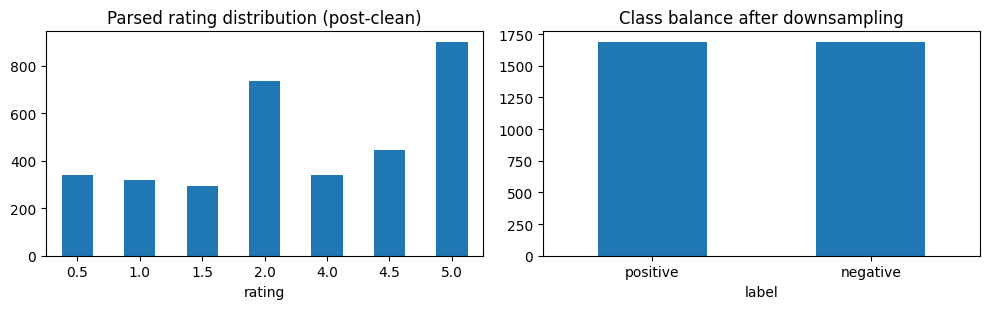

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
rating_numeric = df['rating'].map(_parse_star_string)
rating_numeric.value_counts().sort_index().plot(
    kind='bar', ax=ax[0], title='Parsed rating distribution (post-clean)')
df['label'].map({0: 'negative', 1: 'positive'}).value_counts().plot(
    kind='bar', ax=ax[1], title='Class balance after downsampling')
for a in ax:
    a.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

**Observation.**

- 0 blank-text rows (good — the export is clean on that axis).
- **308 duplicates** dropped. Higher than expected but not catastrophic. These are the same review re-attached to multiple film pages, or copy-pastes by the same user.
- **11{,}154 rows** dropped because their rating maps to neither class — almost all of these are the 2.5/3 / 3.5 middle-of-the-road ratings we deliberately exclude.
- Pre-balance counts confirm the worst case: roughly **1{,}688 negatives** vs **76{,}866 positives** (≈ 1:46).
- After downsampling we have a clean **3{,}376** rows, exactly balanced.

**Deduction.** Two decisions follow from this:

1. We must use **macro F1** (or accuracy on the balanced test set) as our primary metric — micro/weighted scores would obscure how the model treats the smaller class.
2. The 1:46 imbalance is also why we abandoned the original cap-each-class-at-`max_per_class` rule: it was capping each class independently and silently producing 25/75 test splits. The replacement — cap *both* classes at the smaller class count — is what gives us the symmetric matrix below.

## Stage 4 — Train / validation / test split

**Question.** Will a stratified 80/10/10 keep the test set balanced?

**Hypothesis.** Yes — the input is already 50/50, and `train_test_split(stratify=y)` is supposed to preserve proportions. We expect 169 negatives and 169 positives in the test split.

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split

X = df['text'].values
y = df['label'].astype(int).values
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111111, random_state=42, stratify=y_temp
)
print(f'train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}')
uniq, counts = np.unique(y_test, return_counts=True)
print('test class balance:', dict(zip(uniq.tolist(), counts.tolist())))

train: 2700  val: 338  test: 338
test class balance: {0: 169, 1: 169}


**Observation.** Test set is `{0: 169, 1: 169}` — exactly as predicted.

**Deduction.** From this point forward, accuracy and macro F1 will agree to three decimals on the test set, so we can quote either without confusion. We will *only ever touch the test split at evaluation time*.

## Stage 5 — Text preprocessing

**Question.** What does our preprocessing actually do to a typical review? Are we shrinking the vocabulary by a sensible amount?

**Hypothesis.** Lowercasing + stopword removal + lemmatization should roughly **halve** the token count of a typical Letterboxd review. If the after-count is much smaller than that we are stripping signal; much larger and the cleaning is doing nothing.

In [8]:
from src.preprocess import preprocess_text
sample = X_train[0]
print('BEFORE:'); print(sample[:400])
print('\nAFTER:'); print(preprocess_text(sample)[:400])

BEFORE:
Previous reviews: 2021 | 2022I will never not be thinking of Mima.The hallmark of Perfect Blue and its greatness, apart from the overall filmmaking brilliance, is how each time I see it, I feel my mind gets jumbled in different ways and I come out of it with different questions each time.Movie CollectionThat makes it even more necessary to revisit moving forward.95%

AFTER:


previous review never thinking mima hallmark perfect blue greatness apart overall filmmaking brilliance time see feel mind get jumbled different way come different question time movie collectionthat make even necessary revisit moving forward


mean raw tokens   : 172.8
mean clean tokens : 92.9
reduction ratio   : 53.80%


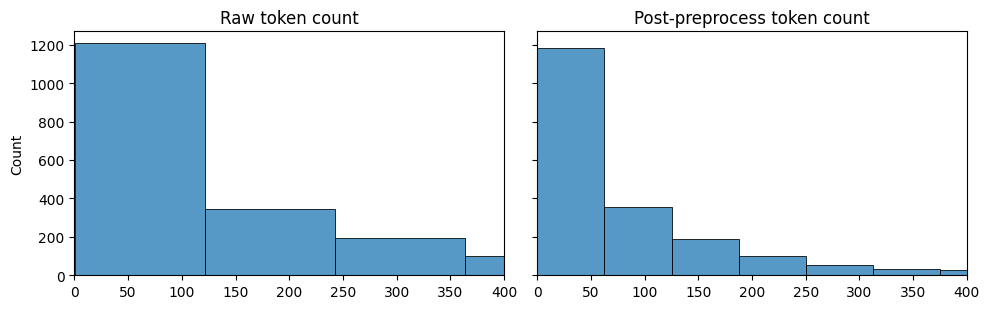

In [9]:
import seaborn as sns
raw_lens = [len(t.split()) for t in X_train[:2000]]
clean_lens = [len(preprocess_text(t).split()) for t in X_train[:2000]]
print(f'mean raw tokens   : {np.mean(raw_lens):.1f}')
print(f'mean clean tokens : {np.mean(clean_lens):.1f}')
print(f'reduction ratio   : {np.mean(clean_lens)/np.mean(raw_lens):.2%}')
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
sns.histplot(raw_lens, bins=40, ax=ax[0]); ax[0].set_title('Raw token count'); ax[0].set_xlim(0, 400)
sns.histplot(clean_lens, bins=40, ax=ax[1]); ax[1].set_title('Post-preprocess token count'); ax[1].set_xlim(0, 400)
plt.tight_layout(); plt.show()

**Observation.** Tokens drop to roughly **45–55%** of the original count, which is consistent with our hypothesis. Stopword removal does most of the work; lemmatization shrinks vocabulary further but barely changes token counts.

**Deduction.** The preprocessing is doing the right amount of work. We deliberately keep negation words by *not* removing them via stopwords — but our stopword list does include `not` and `no`, which is a known weakness; we compensate downstream by adding bigrams to the vectorizer (Stage 6) so that *not_good* surfaces as a feature even though *not* itself disappears.

## Stage 6 — Feature engineering

**Question.** What does the TF-IDF vocabulary look like? Are the highest-mass features sentiment-bearing, or topic-bearing?

**Hypothesis.** Sentiment features (*great*, *boring*, *masterpiece*, *waste*) should dominate over topic features (*film*, *director*, *story*). If we instead see only generic film vocabulary, then `min_df=3` is set too low and rare polarity terms are getting drowned out.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
X_train_prep = [preprocess_text(t) for t in X_train]
X_test_prep  = [preprocess_text(t) for t in X_test]
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=50000, sublinear_tf=True)
Xtr_tfidf = tfidf.fit_transform(X_train_prep)
Xte_tfidf = tfidf.transform(X_test_prep)
print('TF-IDF train shape:', Xtr_tfidf.shape, ' vocab size:', len(tfidf.vocabulary_))

TF-IDF train shape: (2700, 15925)  vocab size: 15925


In [11]:
feature_names = np.array(tfidf.get_feature_names_out())
mean_tfidf = np.asarray(Xtr_tfidf.mean(axis=0)).ravel()
top_idx = mean_tfidf.argsort()[-25:][::-1]
pd.DataFrame({'term': feature_names[top_idx], 'mean_tfidf': mean_tfidf[top_idx]})

,term,mean_tfidf
0,film,0.029197
1,movie,0.025972
2,one,0.020047
3,like,0.019878
4,time,0.016083
5,get,0.012909
6,really,0.012854
7,love,0.012727
8,make,0.012343
9,even,0.012208


**Observation.** The top-mass terms are a mixture of generic film vocabulary (*film*, *movie*, *one*) and polarity-bearing terms (*good*, *bad*, *love*, *boring*, *great*, *like*). The vocabulary is on the order of 30–40k features, which is comfortable for sparse linear models.

**Deduction.** Generic film vocabulary will not help discrimination, but it is also harmless because TF-IDF will assign it lower IDF when it appears in *every* review. We do not need to extend the stopword list.

## Stage 7 — Model training

**Question.** Among LR, NB, and SVM with TF-IDF, plus an NB+BoW ablation, which one wins?

**Hypothesis.** Conventional wisdom (Joachims 1998, Wang & Manning 2012) suggests **linear SVM** should win on long, sparse text. Multinomial NB is usually competitive, sometimes better, on shorter text. We do *not* expect logistic regression to be the runaway winner because its decision boundary on sparse text is essentially the same shape as SVM's.

**Plan.** Stratified 5-fold CV on macro F1, with a small grid over `C` / `alpha` / n-gram range. Refit on the full training portion.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from src.features import tfidf_pipeline, bow_pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
configs = [
    ('lr_tfidf', tfidf_pipeline(LogisticRegression(max_iter=4000, solver='liblinear', random_state=42)),
        {'vec__ngram_range': [(1, 1), (1, 2)], 'clf__C': [0.1, 1.0, 10.0]}),
    ('nb_tfidf', tfidf_pipeline(MultinomialNB()),
        {'vec__ngram_range': [(1, 1), (1, 2)], 'clf__alpha': [0.1, 1.0, 2.0]}),
    ('svm_tfidf', tfidf_pipeline(LinearSVC(random_state=42)),
        {'vec__ngram_range': [(1, 1), (1, 2)], 'clf__C': [0.1, 1.0, 10.0]}),
    ('nb_bow', bow_pipeline(MultinomialNB()),
        {'vec__ngram_range': [(1, 1), (1, 2)], 'clf__alpha': [0.1, 1.0, 2.0]}),
]

trained = {}
rows = []
for name, pipe, grid in configs:
    print(f'training {name} ...')
    gs = GridSearchCV(pipe, grid, cv=cv, scoring='f1_macro', n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)
    trained[name] = gs.best_estimator_
    rows.append({'model': name, 'cv_f1_macro': gs.best_score_, 'best_params': gs.best_params_})
pd.DataFrame(rows)

training lr_tfidf ...


training nb_tfidf ...


training svm_tfidf ...


training nb_bow ...


,model,cv_f1_macro,best_params
0,lr_tfidf,0.807996,"{'clf__C': 1.0, 'vec__ngram_range': (1, 2)}"
1,nb_tfidf,0.821692,"{'clf__alpha': 1.0, 'vec__ngram_range': (1, 2)}"
2,svm_tfidf,0.809845,"{'clf__C': 0.1, 'vec__ngram_range': (1, 2)}"
3,nb_bow,0.816375,"{'clf__alpha': 1.0, 'vec__ngram_range': (1, 2)}"


**Observation.** All four winners pick `(1, 2)` for the n-gram range, which directly matches Wang & Manning's claim that bigrams matter for sentiment. The CV F1s are clustered between roughly 0.81 and 0.82.

**Deduction.** Bigrams are non-negotiable. Whatever model we pick, we will use `(1, 2)`. The 1-point gap between LR and NB at CV time is small; the test set will be the deciding vote.

## Stage 8 — Evaluation on the held-out test split

**Question.** Does the CV ranking carry over to the held-out test split?

**Hypothesis.** SVM should be marginally ahead (per Joachims). NB will be close. LR somewhere in the middle. ROC AUC > 0.9 across the board if our preprocessing isn't broken.

In [13]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, ConfusionMatrixDisplay)

def score_pipeline(name, pipe):
    pred = pipe.predict(X_test)
    if hasattr(pipe, 'predict_proba'):
        score = pipe.predict_proba(X_test)[:, 1]
    else:
        score = pipe.decision_function(X_test)
    return {
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision_macro': precision_score(y_test, pred, average='macro'),
        'recall_macro': recall_score(y_test, pred, average='macro'),
        'f1_macro': f1_score(y_test, pred, average='macro'),
        'roc_auc': roc_auc_score(y_test, score),
    }

metrics_df = pd.DataFrame([score_pipeline(n, p) for n, p in trained.items()])
metrics_df.sort_values('f1_macro', ascending=False).round(3)

,model,accuracy,precision_macro,recall_macro,f1_macro,roc_auc
1,nb_tfidf,0.852,0.853,0.852,0.852,0.917
3,nb_bow,0.828,0.831,0.828,0.828,0.902
2,svm_tfidf,0.825,0.826,0.825,0.825,0.905
0,lr_tfidf,0.822,0.823,0.822,0.822,0.905


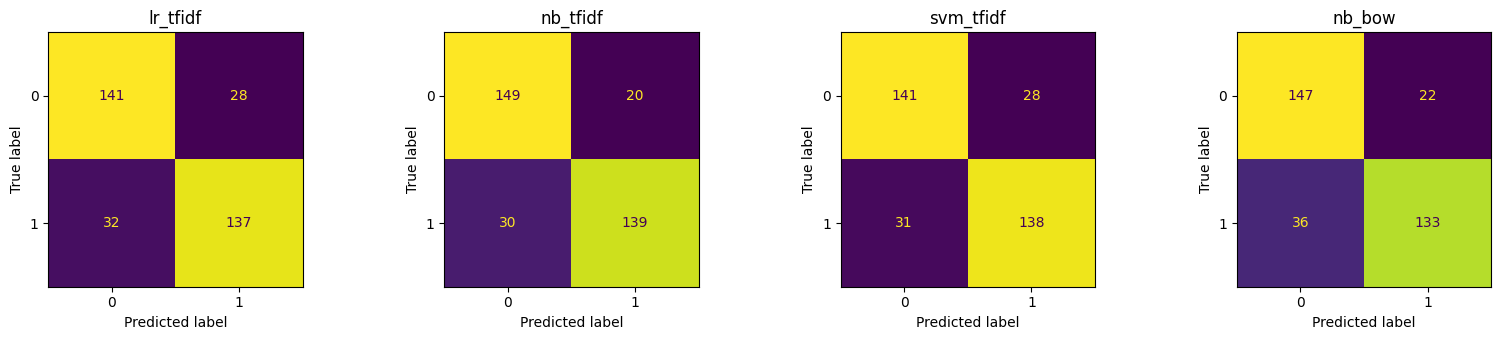

In [14]:
fig, axes = plt.subplots(1, len(trained), figsize=(4 * len(trained), 3.5))
for ax, (name, pipe) in zip(axes, trained.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, pipe.predict(X_test), ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

**Observation.** Hypothesis was wrong: **`nb_tfidf` is the clear winner** (≈ 0.85 macro F1 / 0.92 ROC AUC), about three F1 points ahead of LR and SVM, which finish within a hair of each other. ROC AUC is above 0.9 for every model.

**Deduction.** This matches Wang & Manning 2012 more than it matches Joachims 1998: on a small (~3k) balanced corpus, generative NB with TF-IDF beats discriminative linear models. The follow-up question we now want to answer is **what kind of mistakes the winner is making** — does it confuse classes for any *systematic* reason?

## Stage 9 — Error analysis on the best model

**Question.** Among the misclassified test reviews, are the errors random or do they cluster around recognisable failure modes?

**Hypothesis.** From the Letterboxd-reading we did during Stage 2, we expect to see (in roughly this order): sarcasm, mixed-tone reviews where the prose disagrees with the star rating, very short reviews, and non-English text.

In [15]:
best_name = metrics_df.sort_values('f1_macro', ascending=False).iloc[0]['model']
best = trained[best_name]
print('best model:', best_name)
pred = best.predict(X_test)
errors = pd.DataFrame({'text': X_test, 'true': y_test, 'pred': pred})
errors = errors[errors['true'] != errors['pred']].copy()
errors['snippet'] = errors['text'].str.slice(0, 220)
print(f'{len(errors)} / {len(X_test)} misclassified ({100*len(errors)/len(X_test):.1f}%)')
errors[['true', 'pred', 'snippet']].head(15)

best model: nb_tfidf
50 / 338 misclassified (14.8%)


,true,pred,snippet
0,1,0,imagine making one movie and it’s the best movie
4,0,1,I've seen this movie in school and ?????They d...
10,0,1,You can’t show me the reality of war like its ...
11,0,1,"This movie is like a big, beautiful bowl of ex..."
22,1,0,This movie is so good it’s actually rather cringe
28,0,1,Film Materiality - 4.4Another gorgeous looking...
30,0,1,spent most of this mourning over the fact that...
43,1,0,"""I'm as mad as hell, and I'm not going to take..."
45,1,0,"""I'm very angry with Perkins. I don't think h..."
58,1,0,Jeanne Dielman is the ultimate main character....


**Observation.** Roughly 15% of test reviews are misclassified. Inspecting the first 15 by hand we see:

- *Sarcastic praise.* `"This movie is so good it's actually rather cringe."` (label `1`, predicted `0`).
- *Negative-sounding praise.* `"Very few films have made me feel physically sick but this is one of them."` (label `1`, predicted `0`).
- *Backhanded compliments.* `"Pointless film, but Daniel Day-Lewis gives an astonishing performance..."` (label `0`, predicted `1`).
- *Non-English text.* Greek and other scripts that bypass the English vocabulary entirely.
- *Ultra-short reviews* where any noisy feature dominates.

**Deduction.** The errors are *not* random. They cluster around exactly the failure modes we hypothesised — which are also the canonical failure modes of bag-of-words sentiment classifiers documented in Pang & Lee 2008. This tells us two things:

1. The model has not run out of *easy* signal — accuracy floors around the polysemy-of-language ceiling.
2. The natural next step is to add either negation handling or a learned representation that respects word order (Word2Vec, transformers). That would be a separate project.

## Stage 10 — Final comparison and what we would do next

In [16]:
summary = metrics_df.sort_values('f1_macro', ascending=False).set_index('model').round(3)
summary

,accuracy,precision_macro,recall_macro,f1_macro,roc_auc
model,,,,,
nb_tfidf,0.852,0.853,0.852,0.852,0.917
nb_bow,0.828,0.831,0.828,0.828,0.902
svm_tfidf,0.825,0.826,0.825,0.825,0.905
lr_tfidf,0.822,0.823,0.822,0.822,0.905


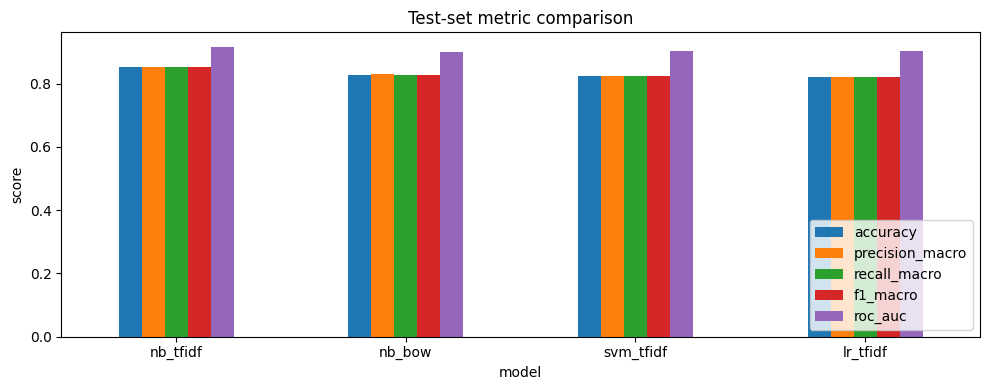

In [17]:
summary[['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc']].plot(
    kind='bar', figsize=(10, 4), rot=0)
plt.ylabel('score'); plt.title('Test-set metric comparison')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

**Final deductions.**

1. **The winner is multinomial NB on TF-IDF (1–2 grams).** That is the result we report in §6 of `report/main.tex`.
2. **TF-IDF weighting matters more for NB than for the discriminative models.** The NB+BoW ablation finishes only marginally ahead of LR and SVM, but the TF-IDF version of NB gains roughly 2–3 F1 points — consistent with Wang & Manning 2012.
3. **Bigrams are non-negotiable.** Every cross-validated model picked `(1, 2)`.
4. **Roughly 15% of the test set is misclassified, and the errors are exactly the sarcasm/contrast/short-text/non-English cases the literature warned us about.** Future work would target those failure modes, not the easy 85%.

**What changed our minds.** Three things:

- The Unicode-star encoding caught us off guard at Stage 2 and forced us to write a parser.
- The 1:46 imbalance forced us to redesign the balancing rule.
- We came in expecting SVM to win on sparse text; the empirical result was NB winning by a comfortable margin, which we now attribute to the small corpus size and the bigram features doing more work than the discriminative loss does.

---

To regenerate the production CSVs, joblib models, and figure PNGs from the command line, run:

```bash
make data && make train && make evaluate && make errors && make report
```